In [3]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import PIL

In [97]:
df = pd.read_csv("cbis_ddsm_dataset/csv/calc_case_description_train_set.csv")

In [98]:
df_dicom = pd.read_csv("cbis_ddsm_dataset/csv/dicom_info.csv")
df_dicom['SeriesDescription'].unique()

array(['cropped images', 'full mammogram images', nan, 'ROI mask images'],
      dtype=object)

In [99]:
df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [100]:
df['pathology'].value_counts()

pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64

### teste dataframe

In [101]:
dicom_data = pd.read_csv("cbis_ddsm_dataset/csv/dicom_info.csv")
image_dir = 'cbis_ddsm_dataset/jpeg'

In [102]:
df_dicom['SeriesDescription'].unique()

array(['cropped images', 'full mammogram images', nan, 'ROI mask images'],
      dtype=object)

In [103]:
dicom_data.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [104]:
cropped_images = dicom_data[dicom_data.SeriesDescription == 'cropped images'].image_path

In [105]:
cropped_images.head()

0     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
3     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
6     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
7     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
10    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...
Name: image_path, dtype: object

In [106]:
cropped_images = cropped_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
cropped_images.head()

0     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
3     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
6     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
7     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
10    cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: object

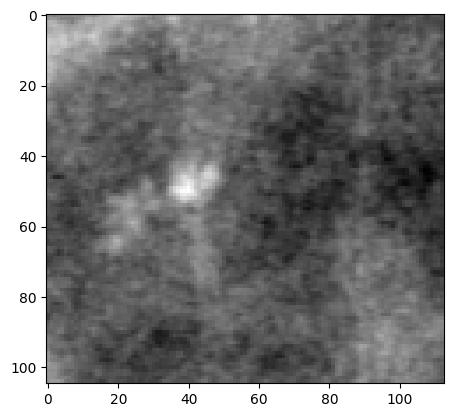

In [107]:
for file in cropped_images[0:10]:
    cropped_images_show = PIL.Image.open(file)
    gray_img= cropped_images_show.convert("L")
    plt.imshow(gray_img, cmap='gray')

In [108]:
full_mammogram_images = dicom_data[dicom_data.SeriesDescription == 'full mammogram images'].image_path
full_mammogram_images.head()

1     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
11    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.210396...
12    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.749566...
15    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.987658...
Name: image_path, dtype: object

In [109]:
full_mammogram_images = full_mammogram_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
full_mammogram_images.head()

1     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
2     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
11    cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
12    cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
15    cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: object

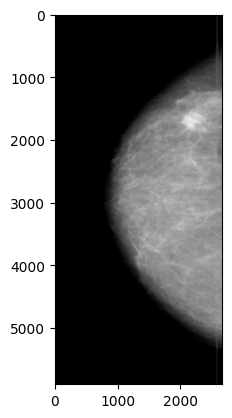

In [110]:
for file  in full_mammogram_images[0:10]:
    full_mammogram_images_show = PIL.Image.open(file)
    gray_img= full_mammogram_images_show.convert("L")
    plt.imshow(gray_img, cmap='gray')

In [111]:
ROI_mask_images = dicom_data[dicom_data.SeriesDescription == 'ROI mask images'].image_path
ROI_mask_images.head()

5     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
8     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
9     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...
14    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.236373...
20    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.357008...
Name: image_path, dtype: object

In [112]:
ROI_mask_images = ROI_mask_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
ROI_mask_images.head()


5     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
8     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
9     cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
14    cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
20    cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
Name: image_path, dtype: object

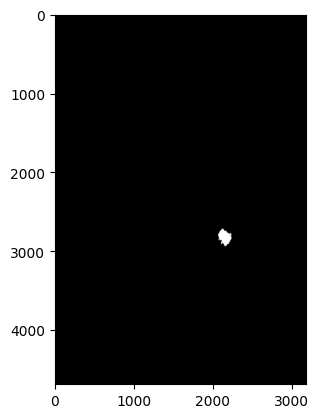

In [113]:
for file  in ROI_mask_images[0:10]:
    ROI_mask_images_show = PIL.Image.open(file)
    gray_img= ROI_mask_images_show.convert("L")
    plt.imshow(gray_img, cmap='gray')


In [114]:
image_dir = 'cbis_ddsm_dataset/jpeg'
full_mammogram_images = dicom_data[dicom_data.SeriesDescription == 'full mammogram images'].image_path
cropped_images = dicom_data[dicom_data.SeriesDescription == 'cropped images'].image_path
roi_mask_images = dicom_data[dicom_data.SeriesDescription == 'ROI mask images'].image_path

full_mammogram_images = full_mammogram_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
cropped_images = cropped_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
roi_mask_images = roi_mask_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg', image_dir))
full_mammogram_images.iloc[0]

'cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg'

In [115]:
full_mammogram_images.shape

(2857,)

In [116]:
roi_mask_images.shape

(3247,)

In [117]:
cropped_images.shape

(3567,)

In [118]:
full_mammogram_dict = dict()
cropped_dict = dict()
roi_mask_dict = dict()

for dicom in full_mammogram_images:
    # print(dicom)
    key = dicom.split("/")[2]
    # print(key)
    full_mammogram_dict[key] = dicom
for dicom in cropped_images:
    key = dicom.split("/")[2]
    cropped_dict[key] = dicom
for dicom in roi_mask_images:
    key = dicom.split("/")[2]
    roi_mask_dict[key] = dicom

In [119]:
mass_train_data = pd.read_csv('cbis_ddsm_dataset/csv/mass_case_description_train_set.csv')
mass_test_data = pd.read_csv('cbis_ddsm_dataset/csv/mass_case_description_test_set.csv')
calc_train_data = pd.read_csv('cbis_ddsm_dataset/csv/calc_case_description_train_set.csv')
calc_test_data = pd.read_csv('cbis_ddsm_dataset/csv/calc_case_description_test_set.csv')

In [120]:
mass_train_data.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [124]:
"Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm".split("/")  

['Mass-Training_P_00001_LEFT_CC',
 '1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994',
 '1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515',
 '000000.dcm']

In [123]:
for i, img in enumerate(mass_train_data.values):
    img_name = img[11].split("/")[2]
    print(i, img_name, img[11])
    # if img_name in full_mammogram_dict:
    #     mass_train_data.iloc[i, 11] = full_mammogram_dict[img_name]

    # img_name = img[12].split("/")[2]
    # if img_name in cropped_dict:
    #     mass_train_data.iloc[i, 12] = cropped_dict[img_name]
    
    # img_name = img[13].split("/")[2]
    # if img_name in roi_mask_dict:
    #     mass_train_data.iloc[i, 13] = roi_mask_dict[img_name]

0 1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515 Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
1 1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834 Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.319478999311971442426185353560182990988/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/000000.dcm
2 1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540 Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.347107867812656628709864319310977895697/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/000000.dcm
3 1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162 Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.9590.100.1.2.272600286511817402806912403581910920939/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/000000.dcm
4 1.3.6.1.4.1.9590.100.1.2.410524754913057908920

In [127]:
def fix_image_path_mass(dataset):
    for i, img in enumerate(dataset.values):
        img_name = img[11].split("/")[2]
        if img_name in full_mammogram_dict:
            dataset.iloc[i, 11] = full_mammogram_dict[img_name]

        img_name = img[12].split("/")[2]
        if img_name in cropped_dict:
            dataset.iloc[i, 12] = cropped_dict[img_name]
        
        img_name = img[13].split("/")[2]
        if img_name in roi_mask_dict:
            dataset.iloc[i, 13] = roi_mask_dict[img_name]


In [128]:
fix_image_path_mass(mass_train_data)
fix_image_path_mass(mass_test_data)

In [129]:
mass_train_data.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....


In [130]:
def fix_image_path_calc(dataset):
    for i, img in enumerate(dataset.values):
        img_name = img[11].split("/")[2]
        if img_name in full_mammogram_dict:
            dataset.iloc[i, 11] = full_mammogram_dict[img_name]

        img_name = img[12].split("/")[2]
        if img_name in cropped_dict:
            dataset.iloc[i, 12] = cropped_dict[img_name]
        
        img_name = img[13].split("/")[2]
        if img_name in roi_mask_dict:
            dataset.iloc[i, 13] = roi_mask_dict[img_name]

In [131]:
fix_image_path_calc(calc_train_data)
fix_image_path_mass(calc_test_data)

In [132]:
calc_train_data.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....


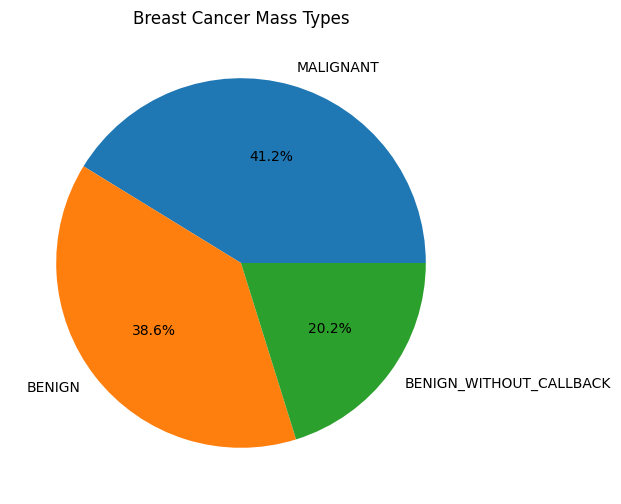

In [137]:
# pathology distributions
value = mass_train_data['pathology'].value_counts() + calc_train_data['pathology'].value_counts()
plt.figure(figsize=(8,6))

plt.pie(value, labels=value.index, autopct='%1.1f%%')
plt.title('Breast Cancer Mass Types', fontsize=12)
plt.show()

In [138]:
import os

Mass Training Dataset


Full Mammograms:

cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.359308329312397897125630708681441180834/1-207.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.89180046211022531834352631483669346540/1-250.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.295360926313492745441868049270168300162/1-067.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.410524754913057908920631336070876889890/1-056.jpg


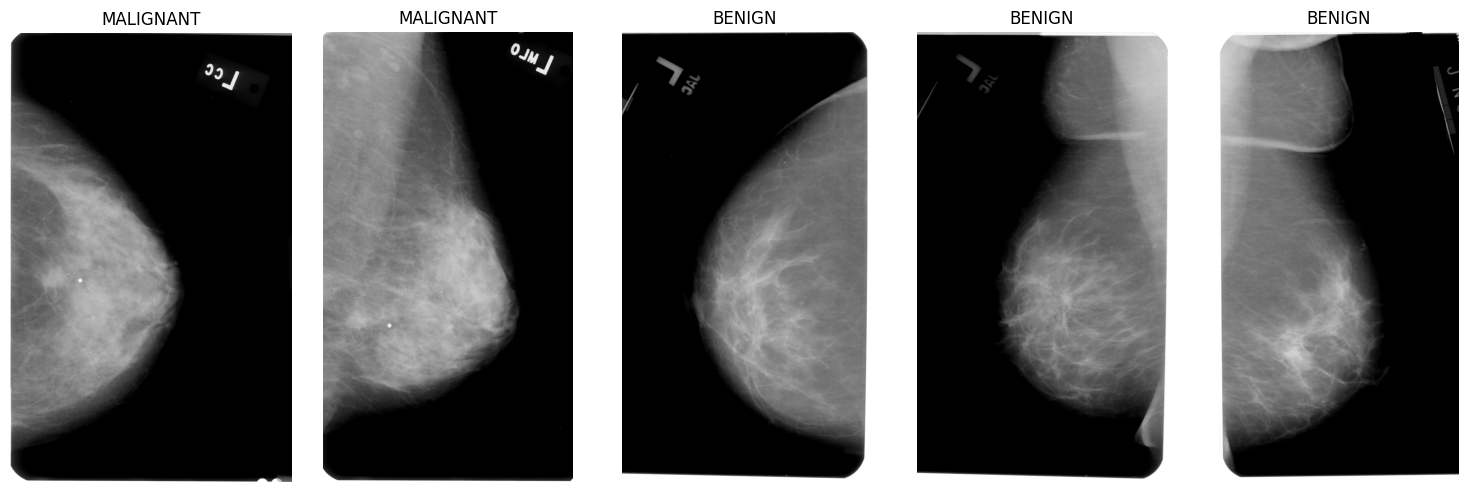

Cropped Mammograms:

cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/2-249.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/1-289.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/2-295.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/2-244.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/1-182.jpg


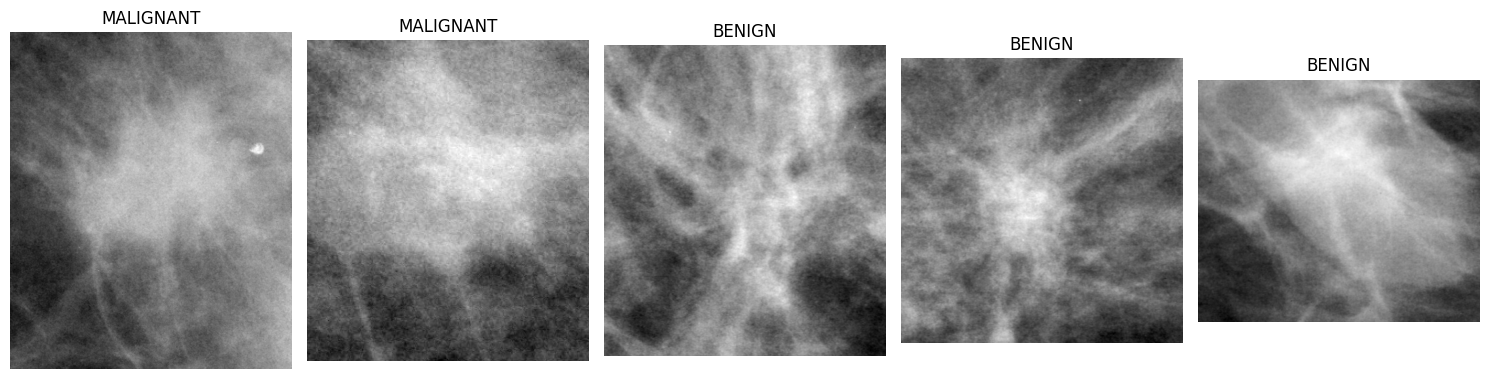

ROI Images:

cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.296736403313792599626368780122205399650/1-250.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.227955274711225756835838775062793186053/2-288.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.429120414011832984817094399141838850375/1-296.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.115134232113001553100559896703407510515/1-245.jpg
cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.12857366312625701203276284233604184846/2-183.jpg


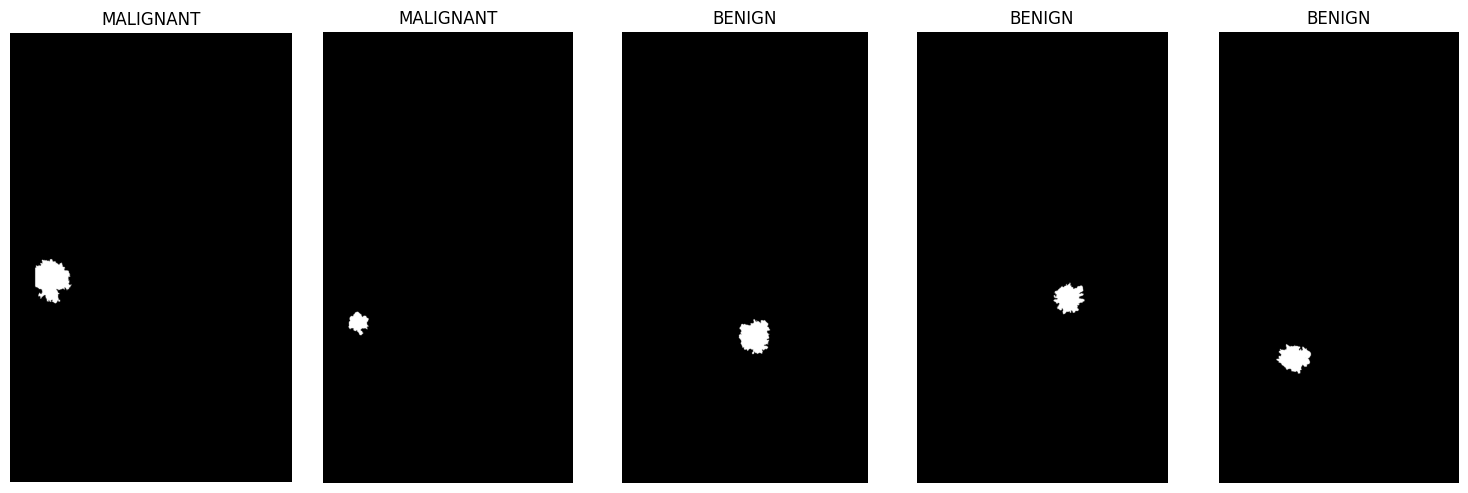

In [140]:
import matplotlib.image as mpimg

def display_images(column, number):
    """displays images in the dataset"""
    # create figure and axes
    number_to_visualize = number
    rows = 1
    cols = number_to_visualize
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5))

    # Loop through rows and display images
    for index, row in mass_train_data.head(number_to_visualize).iterrows():
        image_path = row[column]
        print(image_path)
        # Check if the file exists
        if os.path.exists(image_path):
            image = mpimg.imread(image_path)
            ax = axes[index]
            ax.imshow(image, cmap='gray')
            ax.set_title(f"{row['pathology']}")
            ax.axis('off')
        else:
            print(f"File not found: {image_path}")

    plt.tight_layout()
    plt.show()

print('Mass Training Dataset\n\n')
print('Full Mammograms:\n')
display_images('image file path', 5)
print('Cropped Mammograms:\n')
display_images('cropped image file path', 5)
print('ROI Images:\n')
display_images('ROI mask file path', 5)



In [144]:
mass_train_data

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1313,P_02033,2,RIGHT,MLO,1,mass,IRREGULAR,ILL_DEFINED,3,MALIGNANT,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
1314,P_02079,2,RIGHT,CC,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
1315,P_02079,2,RIGHT,MLO,1,mass,ROUND,SPICULATED,3,MALIGNANT,5,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....
1316,P_02092,2,LEFT,CC,1,mass,IRREGULAR,SPICULATED,3,MALIGNANT,2,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....


In [149]:
df['pathology_binary'] = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)

In [150]:
df

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path,breast density,calc type,calc distribution,pathology_binary
0,P_00001,3.0,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,NaN,NaN,NaN,1
1,P_00001,3.0,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,NaN,NaN,NaN,1
2,P_00004,3.0,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,NaN,NaN,NaN,0
3,P_00004,3.0,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,NaN,NaN,NaN,0
4,P_00004,3.0,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2859,P_02566,NaN,RIGHT,MLO,1,calcification,NaN,NaN,5,MALIGNANT,5,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,2.0,AMORPHOUS-PLEOMORPHIC,SEGMENTAL,1
2860,P_02572,NaN,LEFT,CC,1,calcification,NaN,NaN,0,MALIGNANT,2,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,2.0,AMORPHOUS,CLUSTERED,1
2861,P_02572,NaN,LEFT,MLO,1,calcification,NaN,NaN,0,MALIGNANT,2,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,2.0,AMORPHOUS,CLUSTERED,1
2862,P_02584,NaN,LEFT,CC,1,calcification,NaN,NaN,0,BENIGN,4,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,cbis_ddsm_dataset/jpeg/1.3.6.1.4.1.9590.100.1....,1.0,PLEOMORPHIC,SEGMENTAL,0


In [145]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [146]:
df = pd.concat([mass_train_data, calc_train_data], ignore_index=True)

# Cria coluna binária
df['pathology_binary'] = df['pathology'].apply(lambda x: 1 if x == 'MALIGNANT' else 0)

# Faz o ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

In [151]:
df['pathology_binary'] = df['pathology_binary'].astype(str)

In [152]:
train_gen = datagen.flow_from_dataframe(
    dataframe=df,
    x_col='image file path',
    y_col='pathology_binary',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_dataframe(
    dataframe=df,
    x_col='image file path',
    y_col='pathology_binary',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 2292 validated image filenames belonging to 2 classes.
Found 572 validated image filenames belonging to 2 classes.


In [168]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121

# Backbone pré-treinado
base_model = DenseNet121(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Opcional: pode descongelar depois para fine-tuning

# Construindo a MLP head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

# Compilar com Focal Loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=['accuracy']
)


In [165]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

### LEITURA DICOM

In [2]:
import pydicom

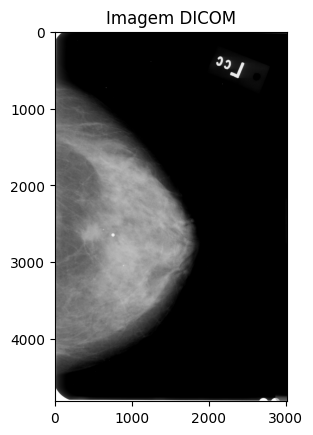

In [11]:
# Caminho para a imagem .dcm
filename = "1-1.dcm"

# Lê o arquivo DICOM
dicom_image = pydicom.dcmread(filename)

# Acessa os dados de pixel
pixels = dicom_image.pixel_array

# Exibe a imagem
plt.imshow(pixels, cmap="gray")
plt.title("Imagem DICOM")
# plt.axis("off")
plt.show()

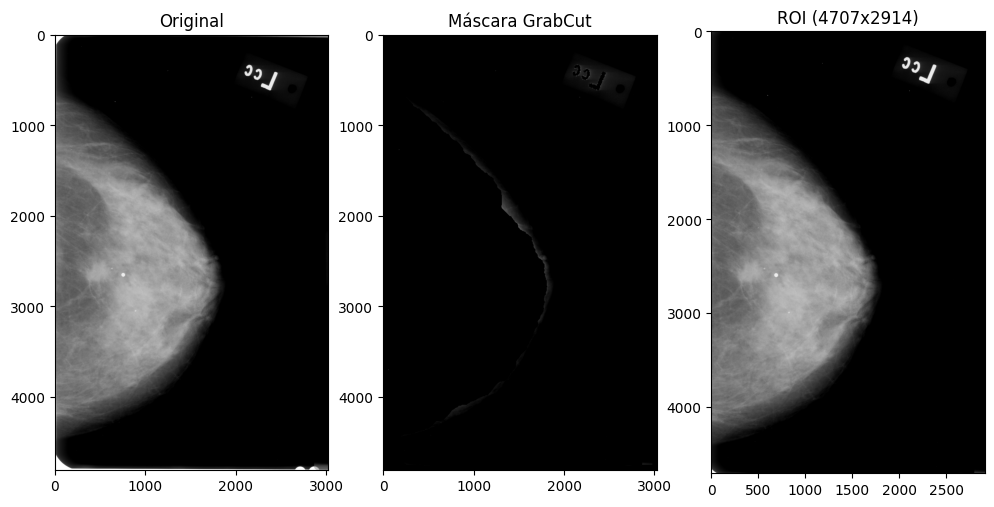

In [27]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Ler a imagem DICOM
filename = "1-1.dcm"
dicom_image = pydicom.dcmread(filename)
pixels = dicom_image.pixel_array

# 2. Normalizar pixels para 0-255 e converter para 3 canais (RGB)
img_normalized = cv2.normalize(pixels, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
img_rgb = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2BGR)  # Convertendo para 3 canais

# 3. Reduzir temporariamente para acelerar o GrabCut (opcional)
scale_percent = 20  # % do tamanho original
width = int(img_rgb.shape[1] * scale_percent / 100)
height = int(img_rgb.shape[0] * scale_percent / 100)
small_img = cv2.resize(img_rgb, (width, height))

# 4. Aplicar GrabCut na imagem reduzida
mask = np.zeros(small_img.shape[:2], np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)

# Define uma ROI retangular inicial (ajuste conforme sua imagem)
rect = (10, 10, width - 20, height - 20)  # (x, y, w, h)

cv2.grabCut(small_img, mask, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
mask = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')

# 5. Redimensionar a máscara de volta ao tamanho original
mask_large = cv2.resize(mask, (img_rgb.shape[1], img_rgb.shape[0]))

# 6. Aplicar a máscara na imagem original (convertida para RGB)
masked_img = img_rgb * mask_large[:, :, np.newaxis]  # Multiplica pelos 3 canais

# 7. Converter de volta para escala de cinza (se necessário)
masked_img_gray = cv2.cvtColor(masked_img, cv2.COLOR_BGR2GRAY)

# 8. Encontrar os limites da ROI
rows = np.any(masked_img_gray > 0, axis=1)
cols = np.any(masked_img_gray > 0, axis=0)
rmin, rmax = np.where(rows)[0][[0, -1]]
cmin, cmax = np.where(cols)[0][[0, -1]]

# 9. Recortar a ROI da imagem original (não normalizada)
roi = pixels[rmin:rmax+1, cmin:cmax+1]

# 10. Exibir resultados
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(pixels, cmap='gray')
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(masked_img_gray, cmap='gray')
plt.title("Máscara GrabCut")

plt.subplot(1, 3, 3)
plt.imshow(roi, cmap='gray')
plt.title(f"ROI ({roi.shape[0]}x{roi.shape[1]})")
plt.show()

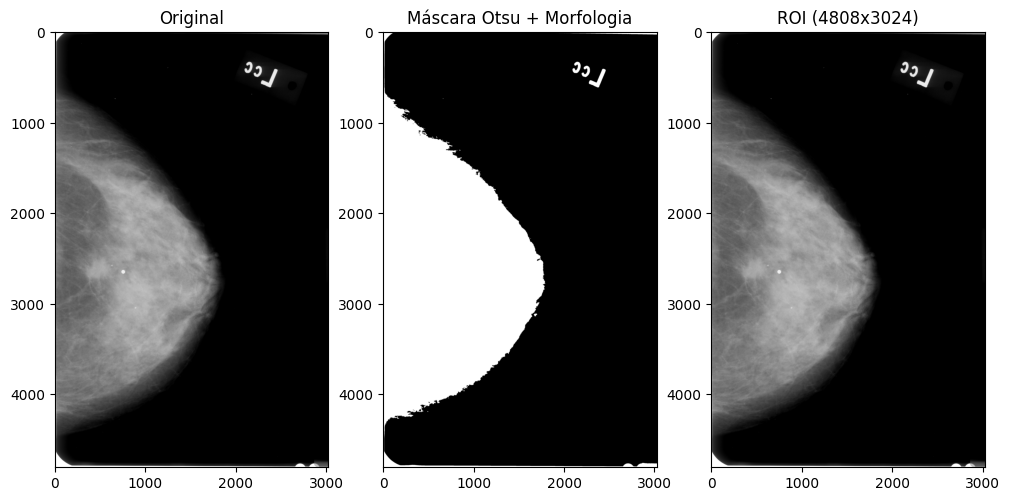

In [28]:
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Ler a imagem DICOM
filename = "1-1.dcm"
dicom_image = pydicom.dcmread(filename)
pixels = dicom_image.pixel_array

# 2. Normalizar para 8-bit (0-255)
img_normalized = cv2.normalize(pixels, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# 3. Aplicar Otsu Thresholding
_, otsu_mask = cv2.threshold(img_normalized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 4. Remover ruídos com operações morfológicas
kernel = np.ones((5, 5), np.uint8)  # Tamanho do kernel (ajuste conforme necessário)
cleaned_mask = cv2.morphologyEx(otsu_mask, cv2.MORPH_OPEN, kernel)  # Remove ruídos brancos
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_CLOSE, kernel)  # Preenche buracos

# 5. Encontrar contornos da ROI
contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(contours, key=cv2.contourArea)  # Pega o maior contorno

# 6. Extrair bounding box da ROI
x, y, w, h = cv2.boundingRect(largest_contour)
roi = pixels[y:y+h, x:x+w]

# 7. Exibir resultados
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(pixels, cmap='gray')
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(cleaned_mask, cmap='gray')
plt.title("Máscara Otsu + Morfologia")

plt.subplot(1, 3, 3)
plt.imshow(roi, cmap='gray')
plt.title(f"ROI ({roi.shape[0]}x{roi.shape[1]})")
plt.show()